In [ ]:
import torch
import requests
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
from io import BytesIO

In [ ]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.eval()
classes = weights.meta["categories"]
preprocess = weights.transforms()

In [ ]:
url1 = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi5.walmartimages.com%2Fseo%2FSpecollect-Soccer-Balls-for-Toddlers-Babies-Mini-Soft-Kids-Soccer-Ball-Perfect-for-Developing-Motor-Skills-and-Safe-Play-Indoors-and-Outdoors_fb1af3d6-efa5-4bfc-aa51-352edc93b3ed.4dc1ce3c78124b9c463ef773f1221fd8.jpeg&f=1&nofb=1&ipt=efed75f75097bef14ade5b88e2d46247ca189ccdb475944ac84d31be00c6ab0c&ipo=images$0"
url2 = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fcdn.nba.com%2Fmanage%2F2022%2F08%2Fnba-ball-general-view-iso.jpg&f=1&nofb=1&ipt=62098f67ad62e2c8c87e7edd92f01491e6313c8a2316ca2b5595244c10bfd065&ipo=images$0"
url3 = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi5.walmartimages.com%2Fseo%2FUniversal-9-Handmade-Baseballs-Hard-Soft-Baseball-Balls-Training-Exercise-Baseball_b7f74146-7afe-48f5-86c4-ceaa86fb6e83.74eaa51372d564b09824dadedb090989.jpeg&f=1&nofb=1&ipt=ae001adbd7f7ad02e4faf564e31a4054bf88bd8a83cd518f9e3439aef1dee20d&ipo=images$0"

image1 = Image.open(BytesIO(requests.get(url1).content)).convert("RGB")
image2 = Image.open(BytesIO(requests.get(url2).content)).convert("RGB")
image3 = Image.open(BytesIO(requests.get(url3).content)).convert("RGB")
images = [image1, image2, image3]

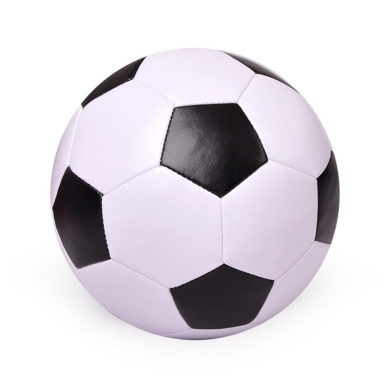

Top 5 Predictions:
soccer ball: 100.00%
volleyball: 0.00%
honeycomb: 0.00%
tennis ball: 0.00%
dumbbell: 0.00%



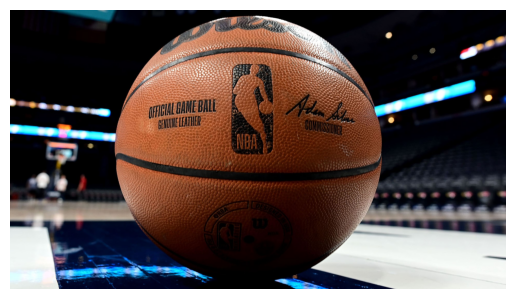

Top 5 Predictions:
basketball: 99.77%
rugby ball: 0.23%
volleyball: 0.00%
baseball: 0.00%
crash helmet: 0.00%



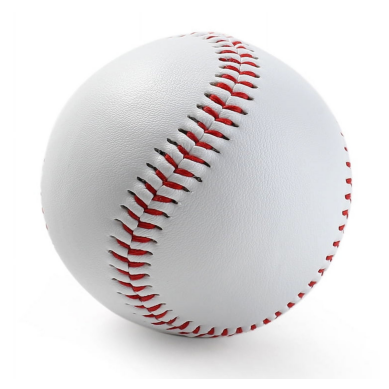

Top 5 Predictions:
baseball: 100.00%
rugby ball: 0.00%
ping-pong ball: 0.00%
maraca: 0.00%
strainer: 0.00%



In [ ]:
for image in images:
  x = preprocess(image).unsqueeze(0)
  with torch.no_grad():
    output = model(x)
  prob = torch.softmax(output[0], dim=0)
  top_five = torch.topk(prob, 5)

  plt.imshow(image)
  plt.axis("off")
  plt.show()

  print("Top 5 Predictions:")
  for i in range(5):
      print(f"{classes[top_five.indices[i]]}: {top_five.values[i] * 100:.2f}%")
  print()